# Baseline Forecasting for NZD/USD Exchange Rates

This notebook builds simple baseline forecasting models for the NZD/USD exchange rate using the cleaned dataset created in the previous notebook.

The goal is not to build a complex model yet. The goal is to establish benchmark forecasts that later ARIMA or machine-learning models must beat.

## 1. Baseline forecasting objective

Exchange rates are difficult to forecast, so simple baselines are important. In this notebook, I will start with a naïve/random-walk forecast, where the next exchange-rate value is predicted to be equal to the most recent observed value.

For NZD/USD, this means:

Tomorrow's NZD/USD exchange rate = Today's NZD/USD exchange rate

## 2. Load processed dataset

This section loads the cleaned and transformed NZD/USD dataset created in the previous notebook.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

df = pd.read_csv('/Users/masonwang/Documents/Projects/Time Series Analysis/NZD-USD-Exchange-Rate-Forecaster/data/processed/cleaned_nzd_usd.csv')

In [73]:
df.head()

,observation_date,DEXUSNZ,log_nzd_usd,nzd_usd_return
0,2016-06-06,0.6931,-0.366581,NaN
1,2016-06-07,0.6981,-0.359393,0.007188
2,2016-06-08,0.7024,-0.353252,0.006141
3,2016-06-09,0.7133,-0.337853,0.015399
4,2016-06-10,0.7069,-0.346866,-0.009013


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  2498 non-null   str    
 1   DEXUSNZ           2498 non-null   float64
 2   log_nzd_usd       2498 non-null   float64
 3   nzd_usd_return    2497 non-null   float64
dtypes: float64(3), str(1)
memory usage: 78.2 KB


In [75]:
df['observation_date'] = pd.to_datetime(df.observation_date, yearfirst=True, format='%Y-%m-%d')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2498 non-null   datetime64[us]
 1   DEXUSNZ           2498 non-null   float64       
 2   log_nzd_usd       2498 non-null   float64       
 3   nzd_usd_return    2497 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 78.2 KB


In [76]:
df['observation_date'].is_monotonic_increasing

True

## 3. Naïve baseline forecast

This section creates a naïve/random-walk forecast for the NZD/USD exchange rate. The naïve forecast predicts that the next observed exchange rate will be equal to the most recent observed exchange rate.

After loading the processed CSV, the `observation_date` column was converted back to a datetime type and the dataset was sorted chronologically. This ensures the data is ready for time-based forecasting.

In [77]:
df['naive_forecast'] = df['DEXUSNZ'].shift(1)
df.head()

,observation_date,DEXUSNZ,log_nzd_usd,nzd_usd_return,naive_forecast
0,2016-06-06,0.6931,-0.366581,NaN,NaN
1,2016-06-07,0.6981,-0.359393,0.007188,0.6931
2,2016-06-08,0.7024,-0.353252,0.006141,0.6981
3,2016-06-09,0.7133,-0.337853,0.015399,0.7024
4,2016-06-10,0.7069,-0.346866,-0.009013,0.7133


The naïve forecast was created by shifting the `DEXUSNZ` series forward by one row. This means each forecast uses the previous observed exchange rate as the prediction for the current observation. The first forecast is missing because there is no earlier observation available.

## 4. Forecast errors

This section calculates the forecast error from the naïve baseline model. Forecast error is defined as the actual observed value minus the forecasted value.

In [78]:
df['naive_error'] = df['DEXUSNZ'] - df['naive_forecast']
df.head()

,observation_date,DEXUSNZ,log_nzd_usd,nzd_usd_return,naive_forecast,naive_error
0,2016-06-06,0.6931,-0.366581,NaN,NaN,NaN
1,2016-06-07,0.6981,-0.359393,0.007188,0.6931,0.0050
2,2016-06-08,0.7024,-0.353252,0.006141,0.6981,0.0043
3,2016-06-09,0.7133,-0.337853,0.015399,0.7024,0.0109
4,2016-06-10,0.7069,-0.346866,-0.009013,0.7133,-0.0064


In [79]:
df['naive_error'].describe()

count    2497.000000
mean       -0.000045
std         0.004146
min        -0.022200
25%        -0.002500
50%         0.000000
75%         0.002500
max         0.016100
Name: naive_error, dtype: float64

The naïve forecast errors are centered very close to zero, suggesting that the baseline forecast is not strongly biased over the sample. Most errors are small, although there are some larger positive and negative misses. The first error is missing because the first observation has no prior exchange-rate value to use as a forecast.

## 5. Accuracy metrics

This section evaluates the naïve baseline forecast using simple forecast accuracy metrics.

In [80]:
valid_errors = df['naive_error'].dropna()

mae_naive = valid_errors.abs().mean()
rmse_naive = np.sqrt((valid_errors ** 2).mean())

print(f"Naïve forecast MAE: {mae_naive}")
print(f"Naïve forecast RMSE: {rmse_naive}")

Naïve forecast MAE: 0.0031502603123748493
Naïve forecast RMSE: 0.004145757441737139


## 6. Baseline accuracy interpretation

The naïve forecast has an MAE of approximately 0.00315 and an RMSE of approximately 0.00415. Since `DEXUSNZ` is measured in U.S. dollars per 1 New Zealand dollar, this means the one-step naïve forecast is typically off by about 0.003 USD per NZD.

The RMSE is higher than the MAE, which means larger forecast errors occur occasionally and are penalized more heavily by RMSE. This naïve forecast will serve as the benchmark that future ARIMA or machine-learning models need to beat.

## 7. Actual vs naïve forecast

This section compares the actual NZD/USD exchange rate against the naïve baseline forecast.

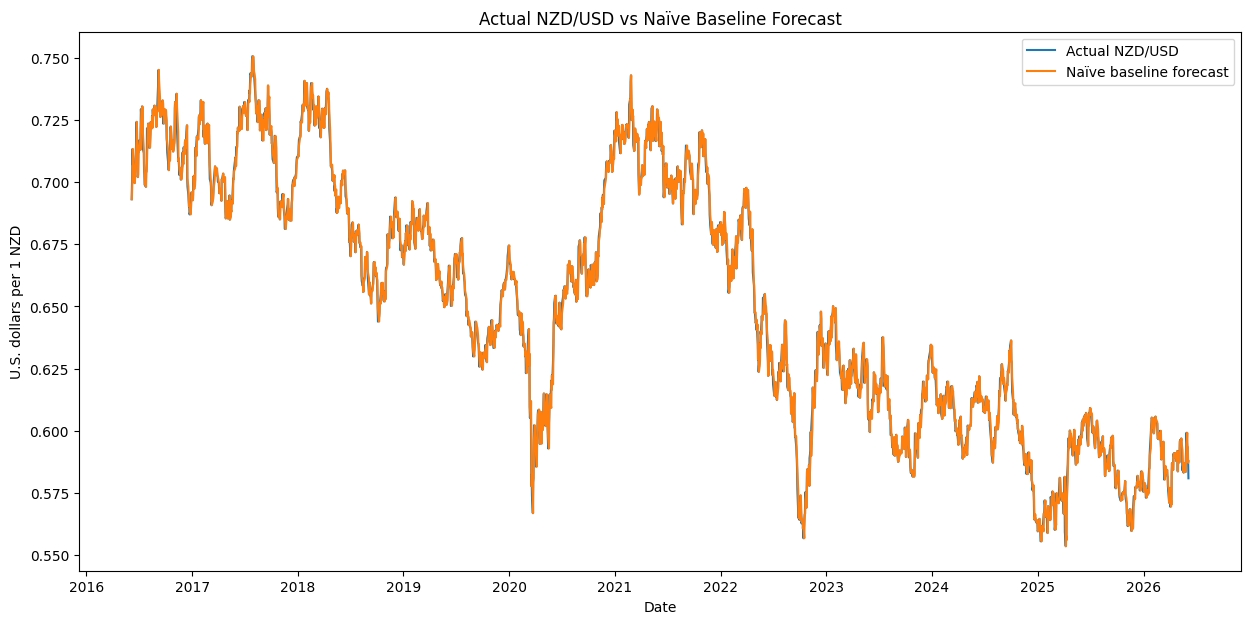

In [81]:
plt.plot(df.observation_date,df.DEXUSNZ,label="Actual NZD/USD")
plt.plot(df.observation_date,df.naive_forecast,label="Naïve baseline forecast")
plt.title("Actual NZD/USD vs Naïve Baseline Forecast")
plt.xlabel("Date")
plt.ylabel("U.S. dollars per 1 NZD")
plt.legend()


The actual NZD/USD exchange rate and the naïve baseline forecast almost completely overlap. This happens because the naïve forecast uses the previous observed exchange rate, and exchange-rate levels are highly persistent from one observation to the next. This visual closeness does not mean the model is highly predictive of exchange-rate changes; it mainly shows that today’s level is usually close to yesterday’s level.

## 8. Naïve forecast error plot

This section plots the naïve forecast errors over time. The forecast error is calculated as the actual exchange rate minus the naïve forecast.

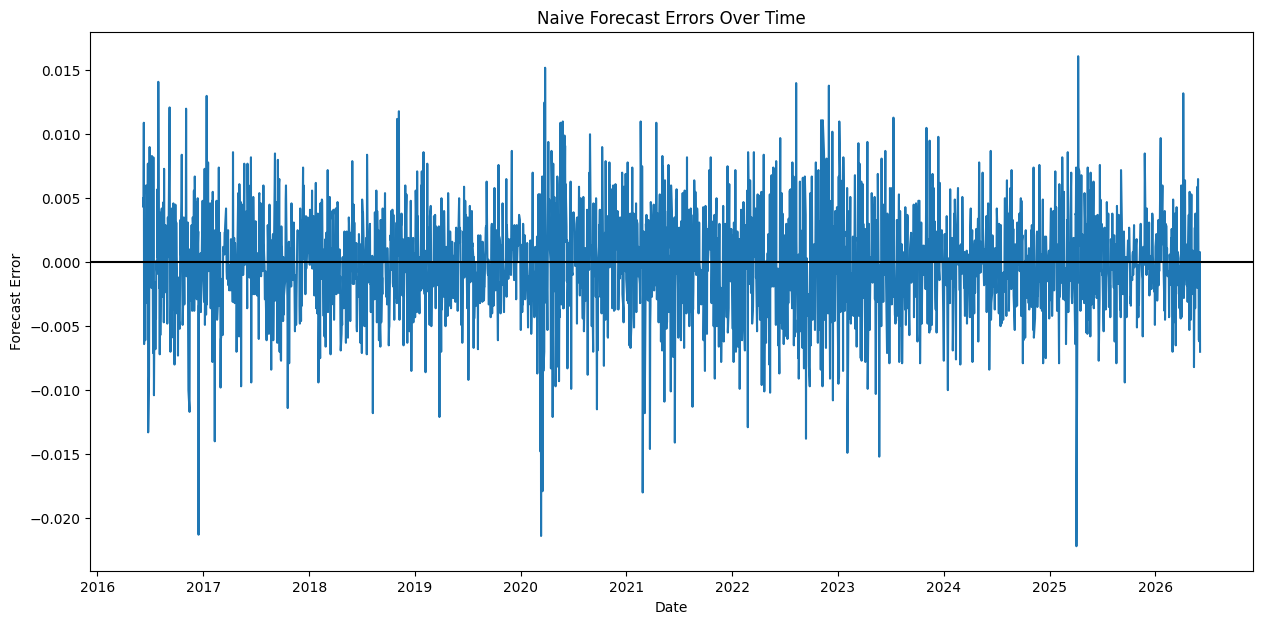

In [82]:
plt.plot(df.observation_date,df.naive_error)
plt.title('Naive Forecast Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Forecast Error')
plt.axhline(y=0, color='black')

The naïve forecast errors fluctuate around zero, suggesting that the baseline forecast is not strongly biased. Most errors are small, but there are occasional larger positive and negative spikes. These larger errors occur when the exchange rate changes sharply from one observation to the next. Future models would need to reduce these errors in order to improve on the naïve baseline.

## 9. Baseline model summary

This notebook created a naïve/random-walk baseline forecast for the NZD/USD exchange rate. The baseline predicts that the next observed exchange rate will equal the previous observed exchange rate.

The naïve forecast closely tracks the actual exchange-rate level because NZD/USD exchange-rate levels are highly persistent. However, this does not mean the model can reliably predict daily changes. The forecast error plot shows that most errors are small and centered around zero, but occasional larger errors occur when the exchange rate moves sharply.

The naïve baseline achieved an MAE of approximately 0.00315 and an RMSE of approximately 0.00415. These values will serve as benchmark metrics for future models. Any ARIMA, regression, or machine-learning model should be compared against this baseline before being considered useful.

## 10. Baseline metrics table

This section stores the naïve baseline forecast metrics in a small summary table. This makes it easier to compare the baseline against future ARIMA, regression, or machine-learning models.

In [85]:
baseline_metrics = pd.DataFrame({'Model': ['Naive baseline'],'MAE': [mae_naive], 'RMSE': [rmse_naive]})
baseline_metrics.head()

,Model,MAE,RMSE
0,Naive baseline,0.00315,0.004146


This table establishes the benchmark that future models need to beat. A more complex model should only be considered useful if it improves on the naïve baseline using the same evaluation method.